In [129]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from auxilary_unparallelized import local_complementation, local_scaling, bitpack_decode, bitpack_encode, draw_graph
from itertools import permutations, combinations
from data_analysis_functions import *
import math
import random
from isomorphism_method import *
import os
import time
import pandas as pd
from scipy.stats import skew, kurtosis
from matplotlib.ticker import MaxNLocator
import scipy.stats as stats


Import all the extracted datasets found

In [144]:
#Chromatic number of OG DONE
with open("og_data/join_og_chromatic_numbers.txt", "r") as f:
    data_og_chrom_number = eval(f.read())
data_og_chrom_number = np.array(data_og_chrom_number)

#Is OG planar: Bool NO NEED
with open("og_data/join_og_is_planar.txt", "r") as f:
    data_og_is_planar = eval(f.read())

data_og_is_planar = np.array(data_og_is_planar)
    
#Number of loops of OG DONE
with open("og_data/join_og_number_of_loops.txt", "r") as f:
    data_og_number_of_loops = eval(f.read())

data_og_number_of_loops = np.array(data_og_number_of_loops)

#Min Chromatic Number in OG DONE
with open("og_data/join_og_minimum_chromatic_number_in_OG.txt", "r") as f:
    data_og_minimum_chromatic_number_in_OG = eval(f.read())

data_og_minimum_chromatic_number_in_OG = np.array(data_og_minimum_chromatic_number_in_OG)

#Density of OG DONE
with open("og_data/join_og_density.txt", "r") as f:
    data_og_density = eval(f.read())

data_og_density = np.array(data_og_density)

#ASPL of OG DONE
data_og_aspl = np.loadtxt('og_data/join_final_aspl_large_run.txt')

#Diameter of OG
with open("og_data/mc_1000_og_diameters_n7.txt", "r") as f:
    data_og_diameter = eval(f.read())
    
data_og_diameter = np.array(data_og_diameter)
    


help_array = ["data_og_chrom_number", "data_og_number_of_loops","data_og_minimum_chromatic_number_in_OG","data_og_density", "data_og_aspl", "data_og_diameter"]



**Skewness** is a measure of symmetry, or more precisely, the lack of symmetry. A distribution, or data set, is symmetric if it looks the same to the left and right of the center point.

**Kurtosis** is a measure of whether the data are heavy-tailed or light-tailed relative to a normal distribution. That is, data sets with high kurtosis tend to have heavy tails, or outliers. Data sets with low kurtosis tend to have light tails, or lack of outliers. A uniform distribution would be the extreme case.

In [99]:
def stat_properties(input_np_file,name_of_dataset ,print_resutls = True):
    mean = np.mean(input_np_file)
    std_dev = np.std(input_np_file)
    variance = np.var(input_np_file)
    median = np.median(input_np_file)
    mode = pd.Series(input_np_file).mode()[0]  # First mode (in case there are multiple)
    range_value = np.max(input_np_file) - np.min(input_np_file)
    iqr = np.percentile(input_np_file, 75) - np.percentile(input_np_file, 25)
    skewness = skew(input_np_file)
    kurt = kurtosis(input_np_file)
    
    if print_resutls:
        print(f"Statistical Properties of {str(name_of_dataset)}:\n")
        print(f"Mean:          {mean:.2f}")
        print(f"Standard Deviation: {std_dev:.2f}")
        print(f"Variance:      {variance:.2f}")
        print(f"Median:        {median:.2f}")
        print(f"Mode:          {mode:.2f}")
        print(f"Range:         {range_value:.2f}")
        print(f"Interquartile Range (IQR): {iqr:.2f}")
        print(f"Skewness:      {skewness:.2f}")
        print(f"Kurtosis:      {kurt:.2f}")
    return mean, std_dev, variance, median, mode, range_value, iqr, skewness, kurt


# Friedman-Diaconis rule to compute the optimal number of bins
#TODO: Move it to data analysis functions.
def friedman_diaconis_bins(data):
    # Calculate the interquartile range (IQR)
    q75, q25 = np.percentile(data, [75 ,25])
    iqr = q75 - q25
    
    # Calculate the number of bins
    bin_width = 2 * iqr / len(data)**(1/3)
    num_bins = int(np.ceil((data.max() - data.min()) / bin_width))
    return num_bins

def plot_single_data_metrics(input_np_file, choose_header_name):
    # Create the figure and axes
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Calculate number of bins for histogram using Friedman-Diaconis rule
    num_bins = friedman_diaconis_bins(input_np_file)

    # Histogram
    axes[0].hist(input_np_file, bins=num_bins, color='skyblue', edgecolor='black')
    axes[0].set_title("Histogram")
    axes[0].set_xlabel("Value")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True)
    axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))  # Set y-axis to integer

    # Boxplot
    axes[1].boxplot(input_np_file, patch_artist=True, boxprops=dict(facecolor='lightgreen', edgecolor='black'))
    axes[1].set_title("Boxplot")
    axes[1].set_ylabel("Value")
    axes[1].grid(True)
    axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))  # Set y-axis to integer

    # Add title for the entire figure
    fig.suptitle(f"Histrogram and Box Plot of {str(choose_header_name)}", fontsize=16)

    return fig  # Return the figure object, no plt.show() here

def plot_obs_vs_orbits(input_np_file, label_of_plot, x_label, y_label, title_of_plot):
    # Create the plot
    fig = plt.figure(figsize=(10, 6))
    plt.plot(input_np_file, 'o-', label=str(label_of_plot), color='blue')
    mean = np.mean(input_np_file)
    std = np.std(input_np_file)
    
    # Add mean line and ±1σ range
    plt.axhline(y=mean, color='black', linestyle='-', label=f'Mean: {mean:.2f}')
    plt.fill_between(np.arange(len(input_np_file)), mean - std, mean + std,
                     color='green', alpha=0.2, label=f'±1$\sigma$ ({std:.2f})')

    # Labels and title
    plt.xlabel(str(x_label))
    plt.ylabel(str(y_label))
    plt.title(str(title_of_plot))
    plt.legend()
    plt.grid(True)

    return fig  # Return the figure object, no plt.show() here


Statistical Properties of OG Chromatic Number:

Mean:          9.11
Standard Deviation: 2.46
Variance:      6.04
Median:        10.00
Mode:          12.00
Range:         10.00
Interquartile Range (IQR): 3.00
Skewness:      -0.80
Kurtosis:      0.05


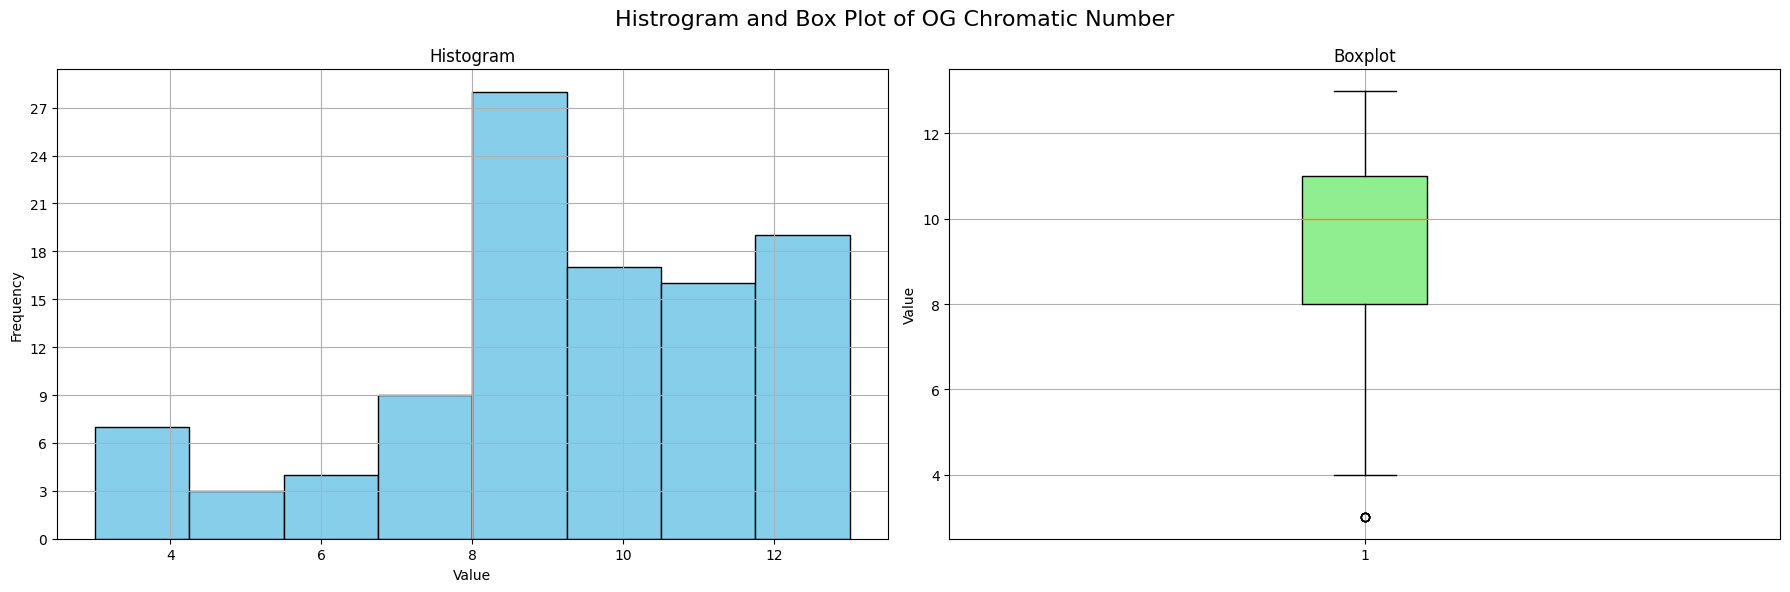

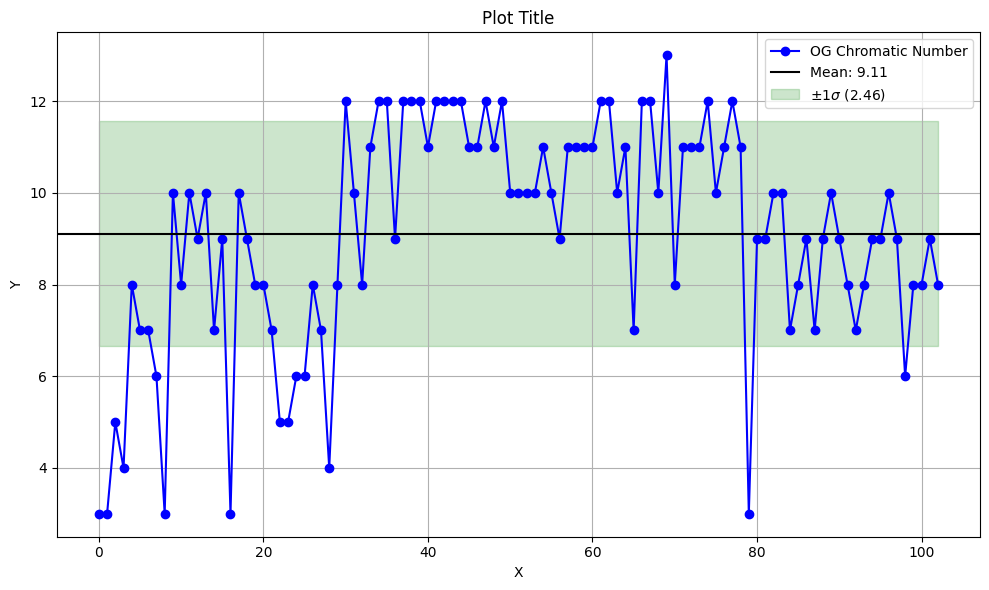

<Figure size 640x480 with 0 Axes>

In [103]:
# Generate the plots without showing them
input_np_file = data_og_chrom_number
stat_properties(input_np_file,"OG Chromatic Number")
fig1 = plot_single_data_metrics(input_np_file, "OG Chromatic Number")
fig2 = plot_obs_vs_orbits(input_np_file, "OG Chromatic Number", "X", "Y", "Plot Title")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready

Statistical Properties of OG ASPL:

Mean:          9.11
Standard Deviation: 2.46
Variance:      6.04
Median:        10.00
Mode:          12.00
Range:         10.00
Interquartile Range (IQR): 3.00
Skewness:      -0.80
Kurtosis:      0.05


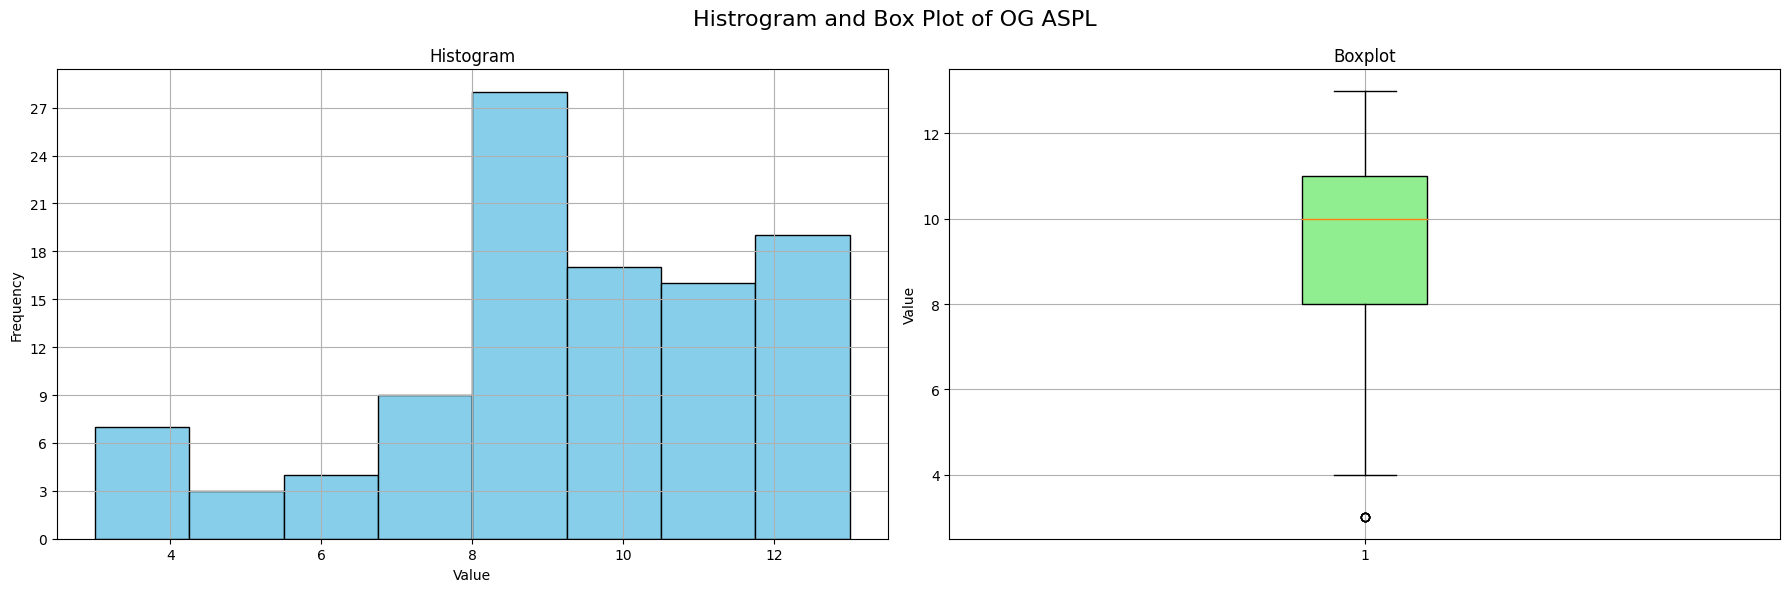

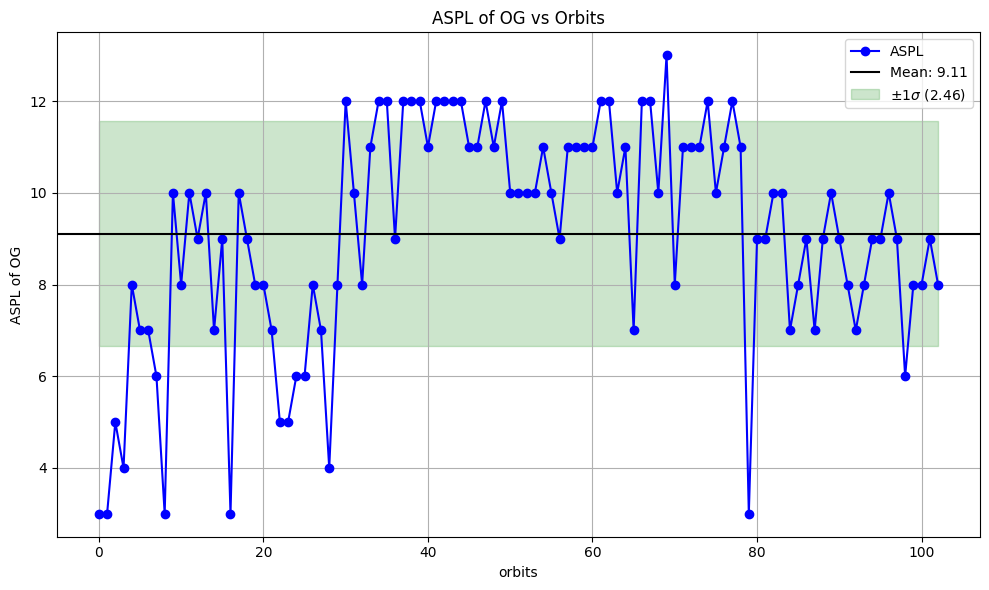

<Figure size 640x480 with 0 Axes>

In [104]:
# Generate the plots without showing them
input_np_file = data_og_chrom_number
stat_properties(input_np_file,"OG ASPL")
fig1 = plot_single_data_metrics(input_np_file,"OG ASPL")
fig2 = plot_obs_vs_orbits(input_np_file,"ASPL", "orbits", "ASPL of OG","ASPL of OG vs Orbits")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready

Statistical Properties of OG Number of Loops:

Mean:          2674.96
Standard Deviation: 4912.78
Variance:      24135405.61
Median:        507.00
Mode:          108.00
Range:         22632.00
Interquartile Range (IQR): 2245.00
Skewness:      2.77
Kurtosis:      7.46


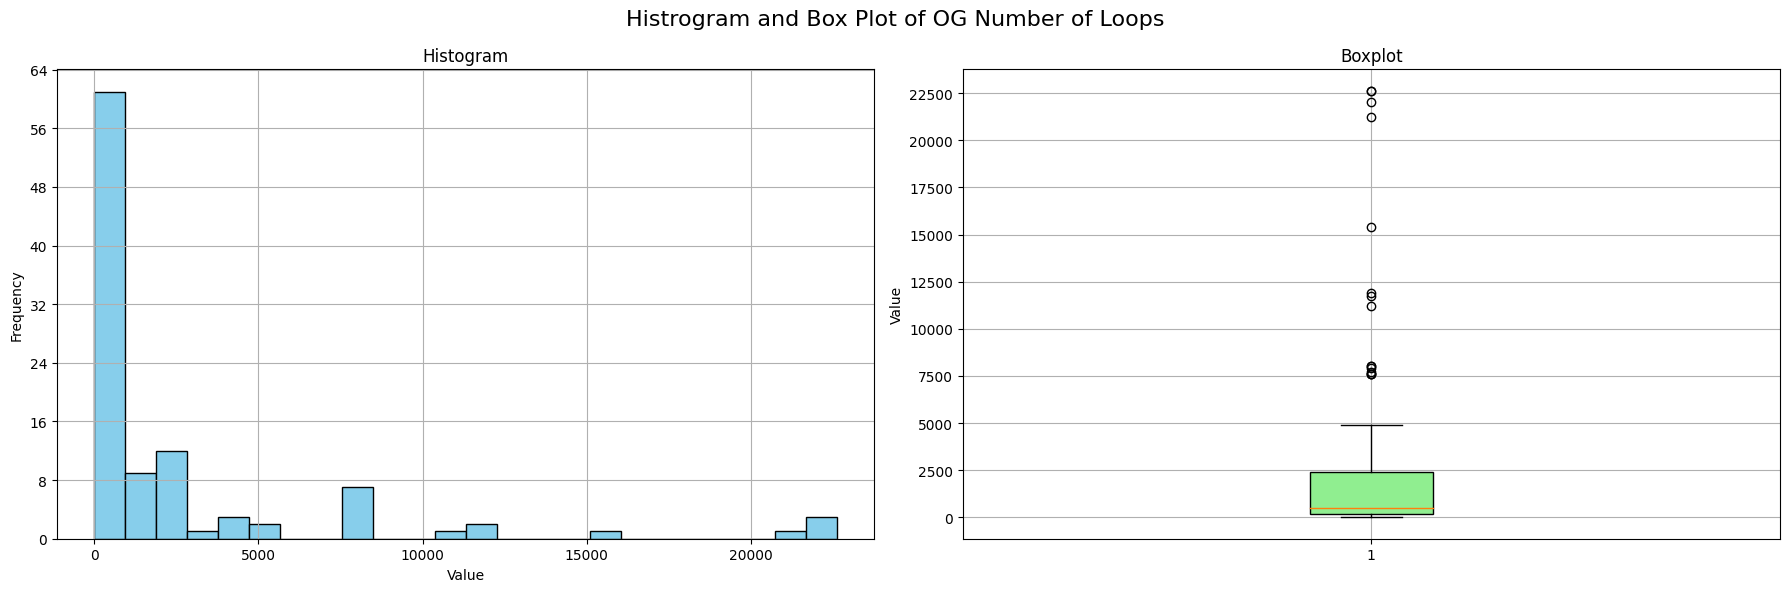

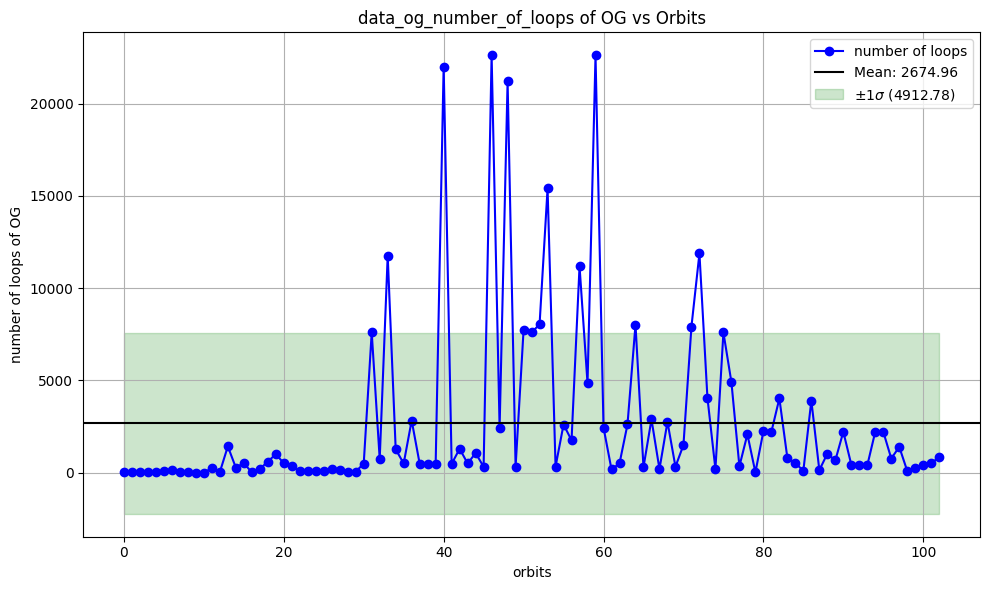

<Figure size 640x480 with 0 Axes>

In [108]:
# Generate the plots without showing them
input_np_file = data_og_number_of_loops
stat_properties(input_np_file,"OG Number of Loops")
fig1 = plot_single_data_metrics(input_np_file,"OG Number of Loops")
fig2 = plot_obs_vs_orbits(input_np_file,"number of loops", "orbits", "number of loops of OG","data_og_number_of_loops of OG vs Orbits")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready

Statistical Properties of $\chi_{s}$:

Mean:          2.40
Standard Deviation: 0.49
Variance:      0.24
Median:        2.00
Mode:          2.00
Range:         1.00
Interquartile Range (IQR): 1.00
Skewness:      0.42
Kurtosis:      -1.83


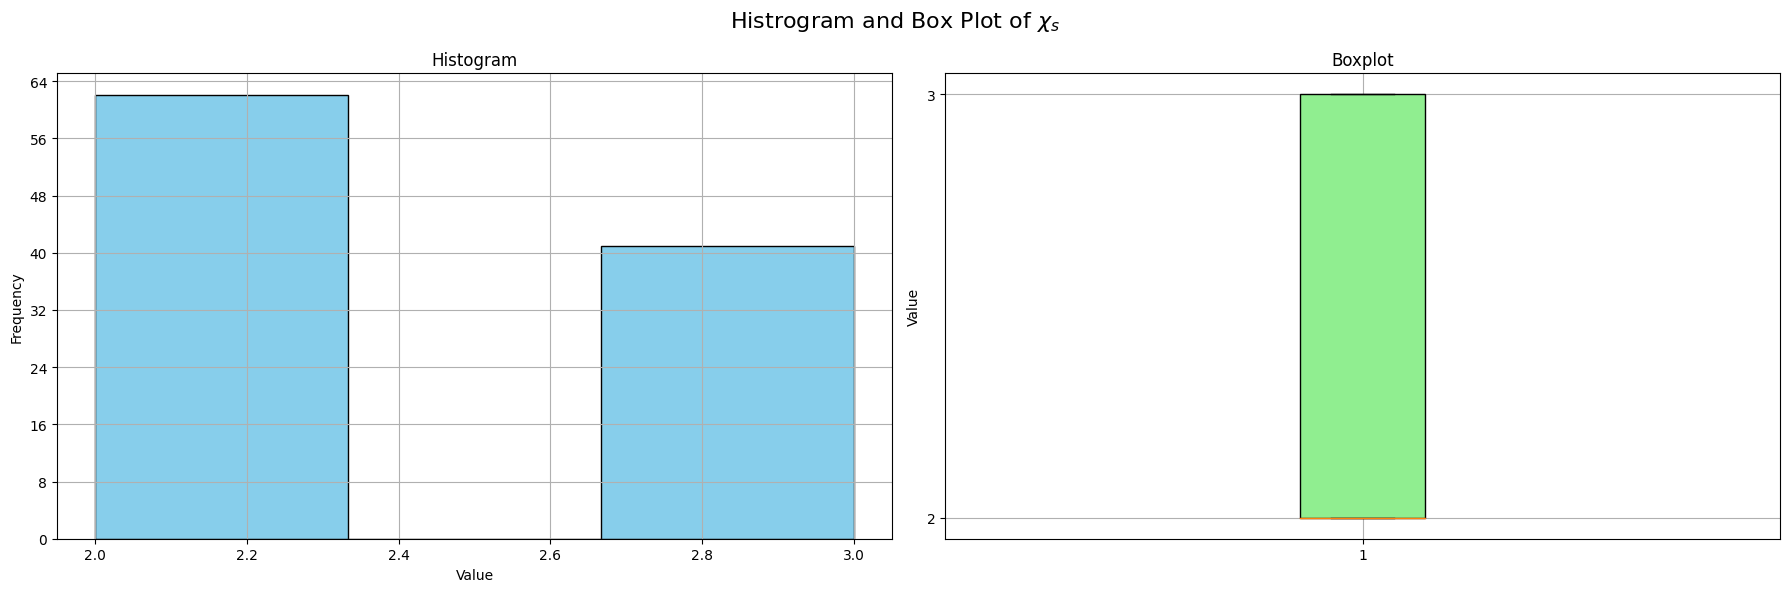

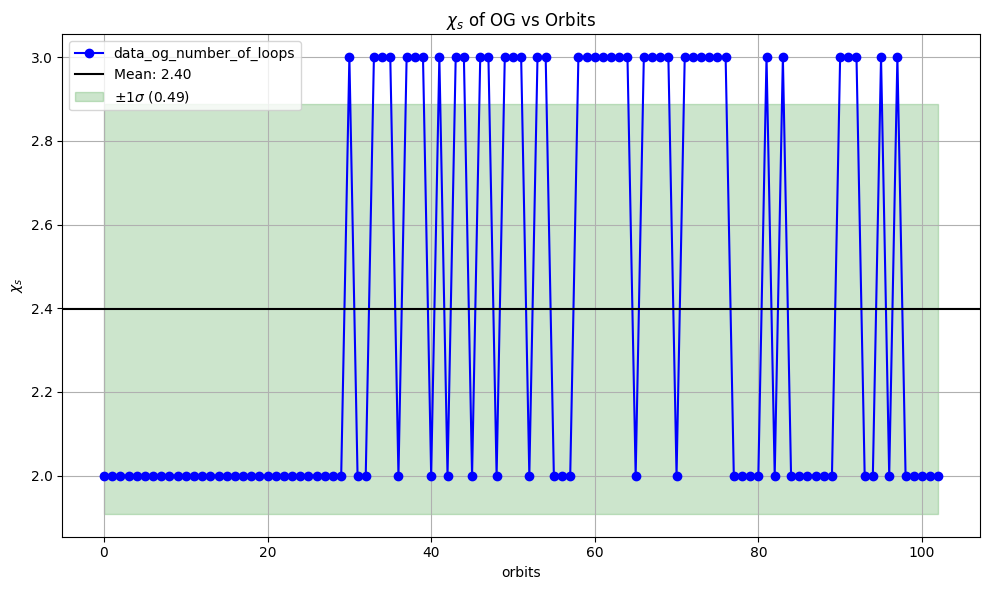

<Figure size 640x480 with 0 Axes>

In [106]:
# Generate the plots without showing them
input_np_file = data_og_minimum_chromatic_number_in_OG
stat_properties(input_np_file,"$\chi_{s}$")
fig1 = plot_single_data_metrics(input_np_file,"$\chi_{s}$")
fig2 = plot_obs_vs_orbits(input_np_file,"data_og_number_of_loops", "orbits", "$\chi_{s}$","$\chi_{s}$ of OG vs Orbits")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready

Statistical Properties of $D_{OG}$:

Mean:          -5.19
Standard Deviation: 2.26
Variance:      5.10
Median:        -5.31
Mode:          -8.21
Range:         9.82
Interquartile Range (IQR): 3.08
Skewness:      0.24
Kurtosis:      -0.65


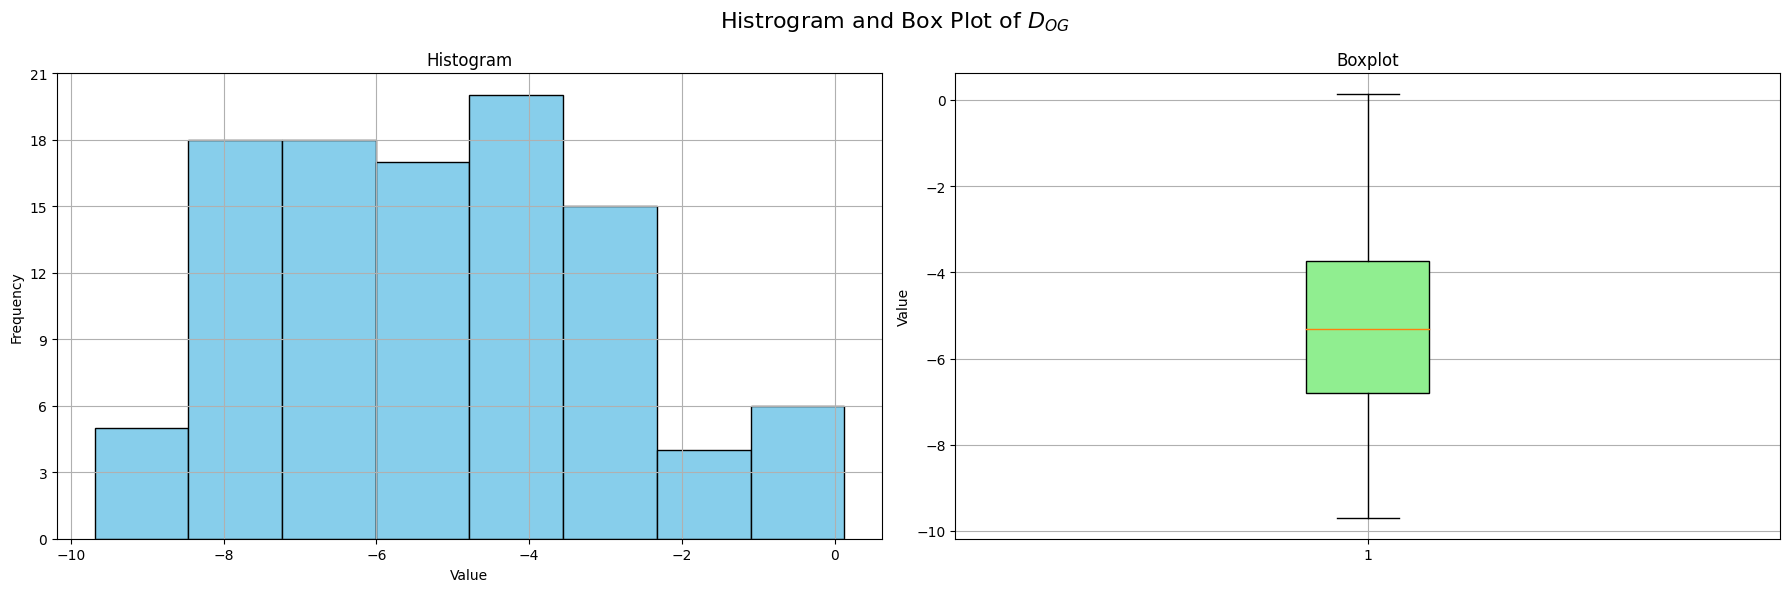

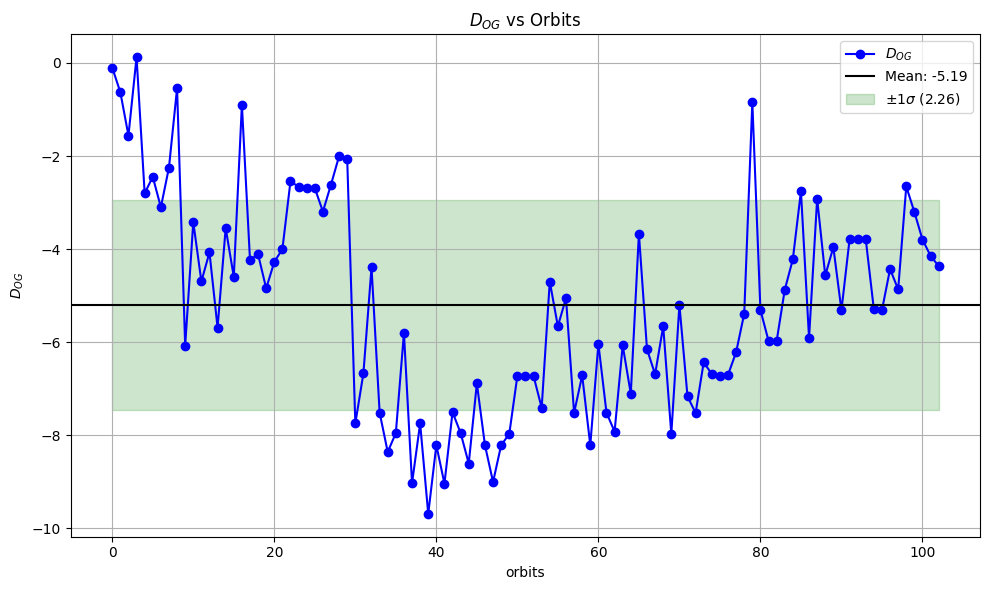

<Figure size 640x480 with 0 Axes>

In [298]:
input_np_file = np.log(data_og_density)
stat_properties(input_np_file,"$D_{OG}$")
fig1 = plot_single_data_metrics(input_np_file,"$D_{OG}$")
fig2 = plot_obs_vs_orbits(input_np_file,"$D_{OG}$", "orbits", "$D_{OG}$","$D_{OG}$ vs Orbits")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready


Statistical Properties of Diameter:

Mean:          6.43
Standard Deviation: 1.56
Variance:      2.42
Median:        7.00
Mode:          7.00
Range:         7.00
Interquartile Range (IQR): 1.50
Skewness:      -0.67
Kurtosis:      0.47


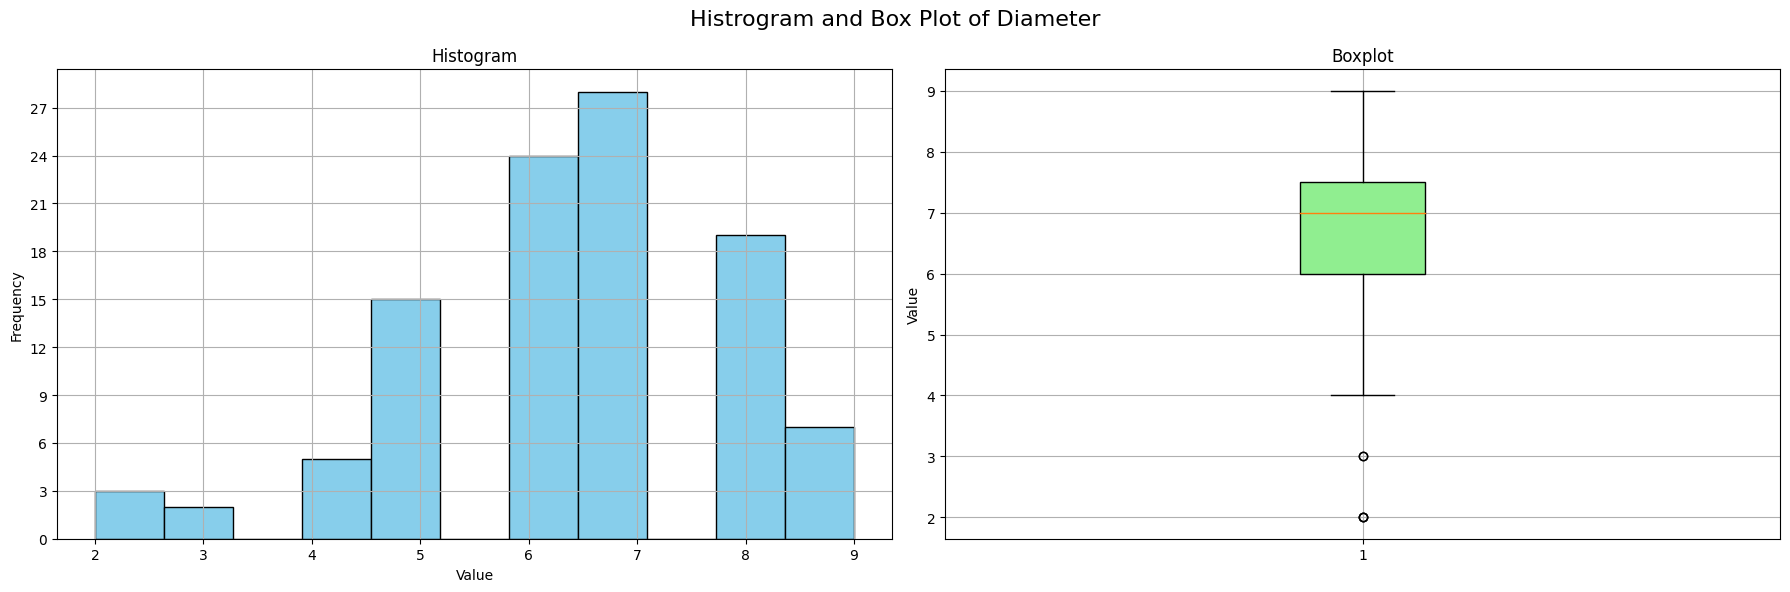

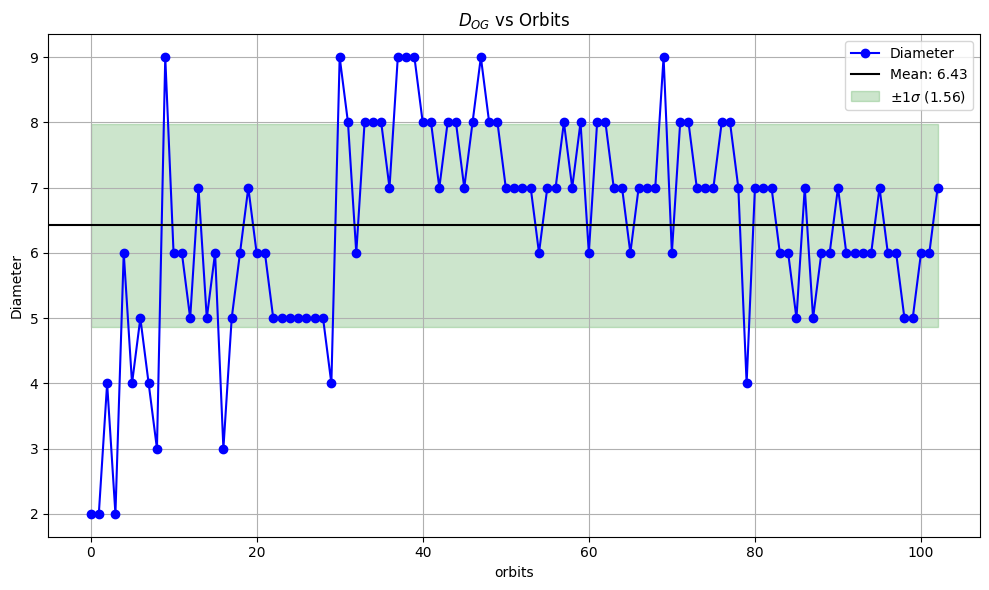

<Figure size 640x480 with 0 Axes>

In [112]:
input_np_file = data_og_diameter
stat_properties(input_np_file,"Diameter")
fig1 = plot_single_data_metrics(input_np_file,"Diameter")
fig2 = plot_obs_vs_orbits(input_np_file,"Diameter", "orbits", "Diameter","$D_{OG}$ vs Orbits")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready


Now we have to build the correlation plots.

In [145]:
help_array

['data_og_chrom_number',
 'data_og_number_of_loops',
 'data_og_minimum_chromatic_number_in_OG',
 'data_og_density',
 'data_og_aspl',
 'data_og_diameter']

In [403]:
#define a dictionary for the coefficients 
pearson_dictionary = dict()

In [404]:
def plot_coef_and_find_pearson(x,y,x_label,y_label):
    dict_name = f"{x_label} vs {y_label}"

    # Ensure the key exists in the dictionary
    if dict_name not in pearson_dictionary:
        pearson_dictionary[dict_name] = {}

    # Calculate the Pearson correlation coefficient
    pearson_dictionary[dict_name]["coef"], pearson_dictionary[dict_name]["pvalue"] = stats.pearsonr(x, y)

    # Access dictionary values before using f-string to avoid syntax error
    coef = pearson_dictionary[dict_name]["coef"]
    pvalue = pearson_dictionary[dict_name]["pvalue"]

    print(f"Pearson correlation coefficient: {coef:.4f}")
    print(f"P-value: {pvalue:.4e}")

    # Scatter plot with logarithmic axis
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='blue', alpha=0.9)

    # Set x-axis to logarithmic scale
    # plt.xscale('log')
    # plt.yscale('log')

    # Labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(f"{x_label} vs {y_label}")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    plt.show()

In [405]:
pearson_dictionary

{}

Pearson correlation coefficient: 0.9391
P-value: 1.1509e-48


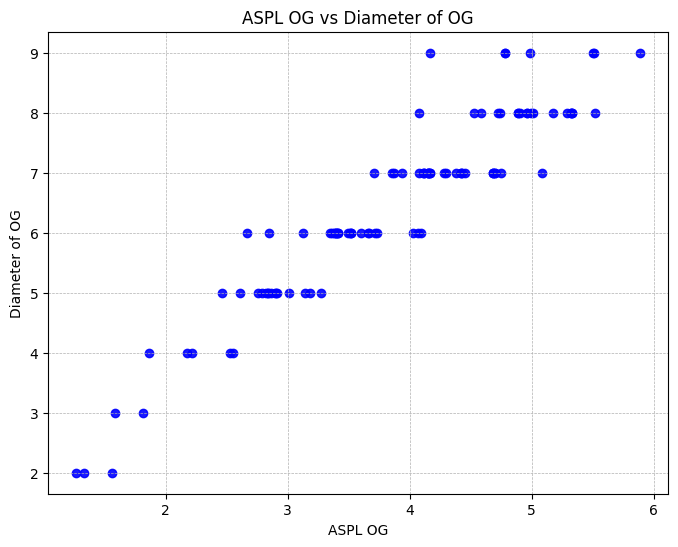

In [406]:
#16
x = data_og_aspl
x_label = "ASPL OG"

y = data_og_diameter
y_label = "Diameter of OG"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: -0.9369
P-value: 6.6158e-48


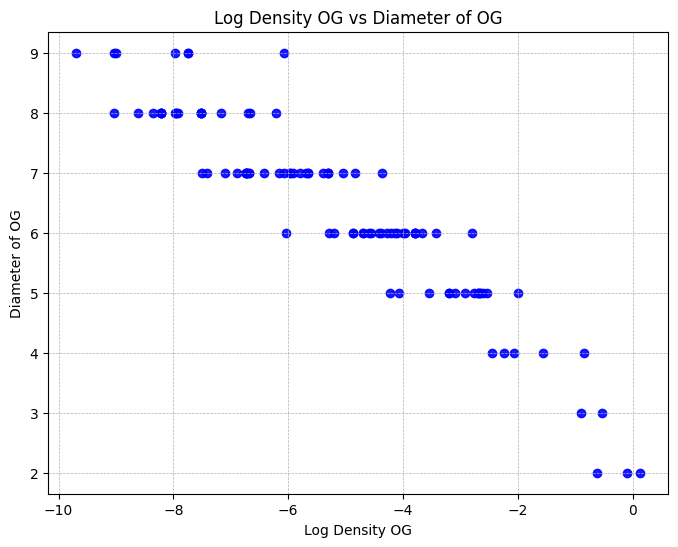

In [407]:
#15
x = np.log(data_og_density)
x_label = "Log Density OG"

y = data_og_diameter
y_label = "Diameter of OG"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: -0.9877
P-value: 3.0500e-83


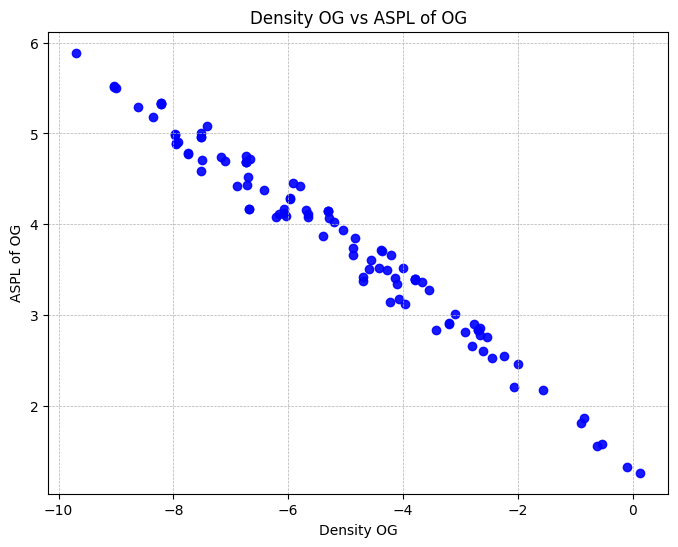

In [408]:
#14
x = np.log(data_og_density)
x_label = "Density OG"

y = data_og_aspl
y_label = "ASPL of OG"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.5545
P-value: 1.2249e-09


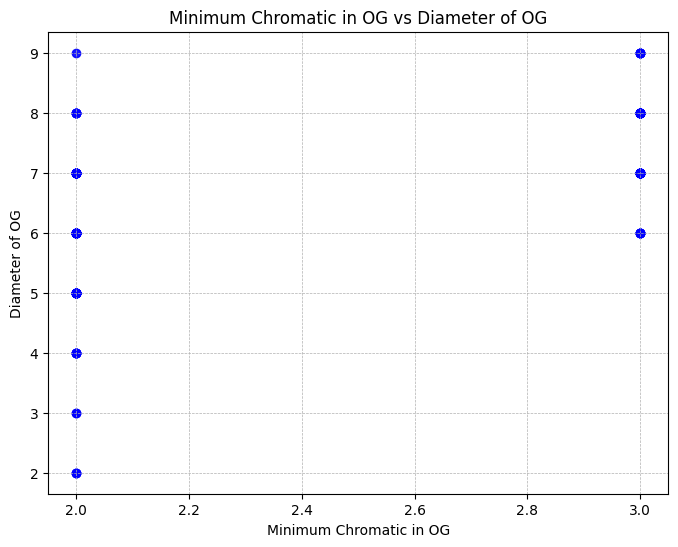

In [409]:
#13
x = data_og_minimum_chromatic_number_in_OG
x_label = "Minimum Chromatic in OG"

y = data_og_diameter
y_label = "Diameter of OG"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.6027
P-value: 1.6281e-11


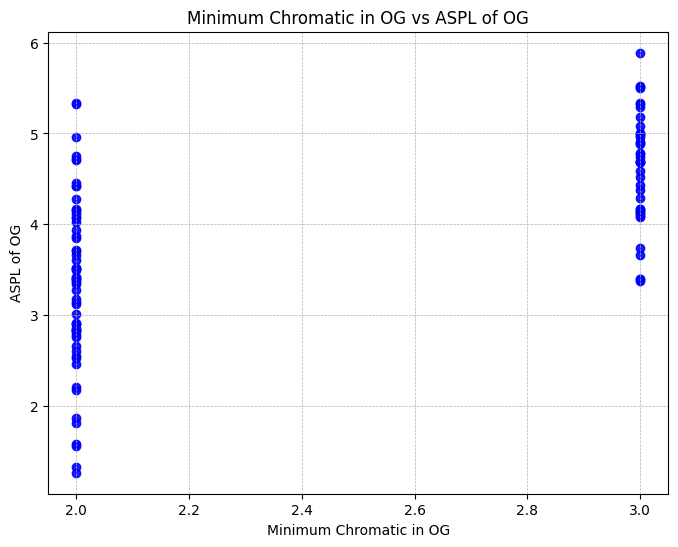

In [410]:
#12
x = data_og_minimum_chromatic_number_in_OG
x_label = "Minimum Chromatic in OG"

y = data_og_aspl
y_label = "ASPL of OG"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: -0.6377
P-value: 4.3827e-13


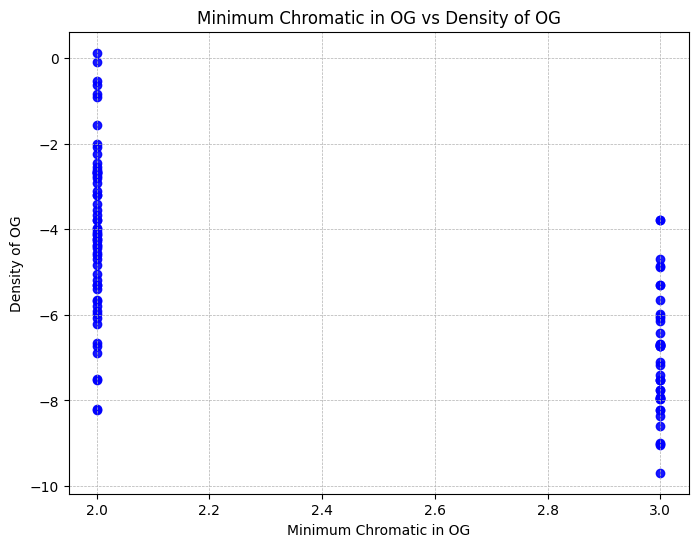

In [411]:
#11
x = data_og_minimum_chromatic_number_in_OG
x_label = "Minimum Chromatic in OG"

y = np.log(data_og_density)
y_label = "Density of OG"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: 0.6266
P-value: 1.4511e-12


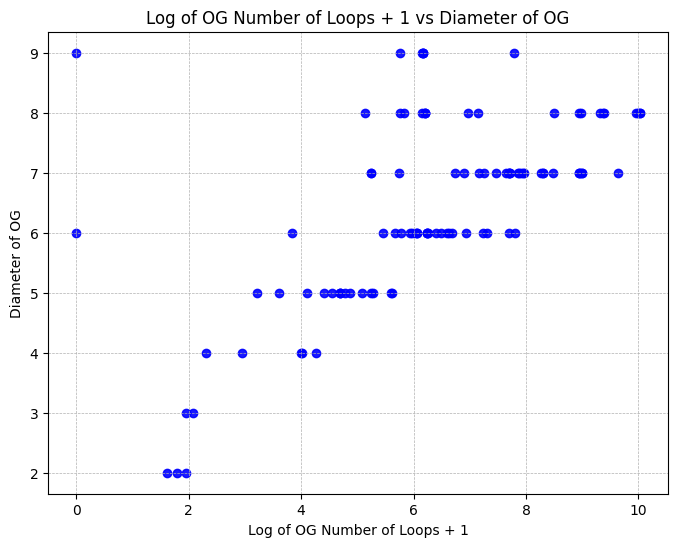

In [412]:
#9
x = np.log(data_og_number_of_loops+1)
x_label = "Log of OG Number of Loops + 1"

y = data_og_diameter
y_label = "Diameter of OG"

plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: 0.7528
P-value: 4.7233e-20


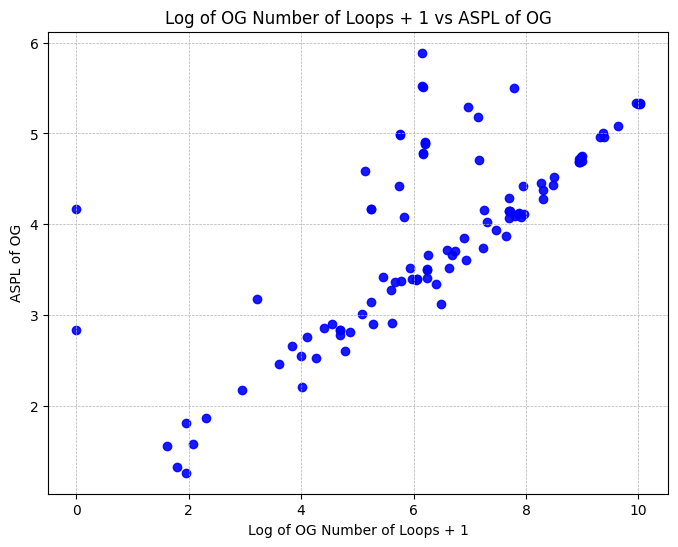

In [413]:
#8
x = np.log(data_og_number_of_loops+1)
x_label = "Log of OG Number of Loops + 1"

y = data_og_aspl
y_label = "ASPL of OG"

plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: -0.6914
P-value: 6.2200e-16


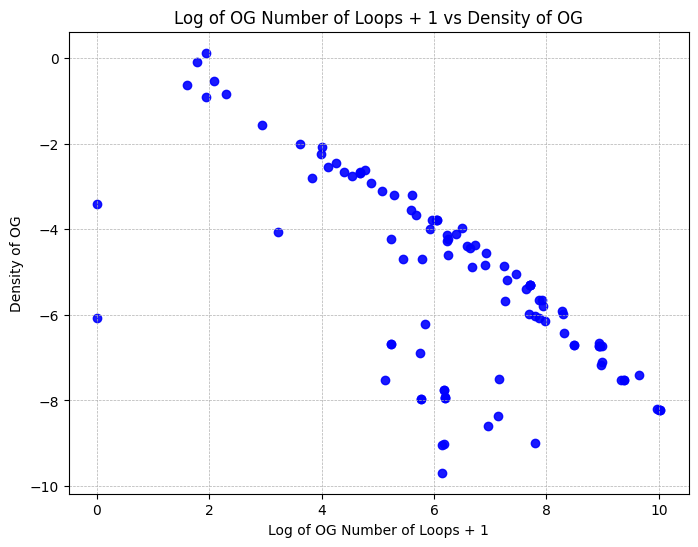

In [414]:
#7
x = np.log(data_og_number_of_loops+1)
x_label = "Log of OG Number of Loops + 1"

y = np.log(data_og_density)
y_label = "Density of OG"

plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: 0.4162
P-value: 1.2313e-05


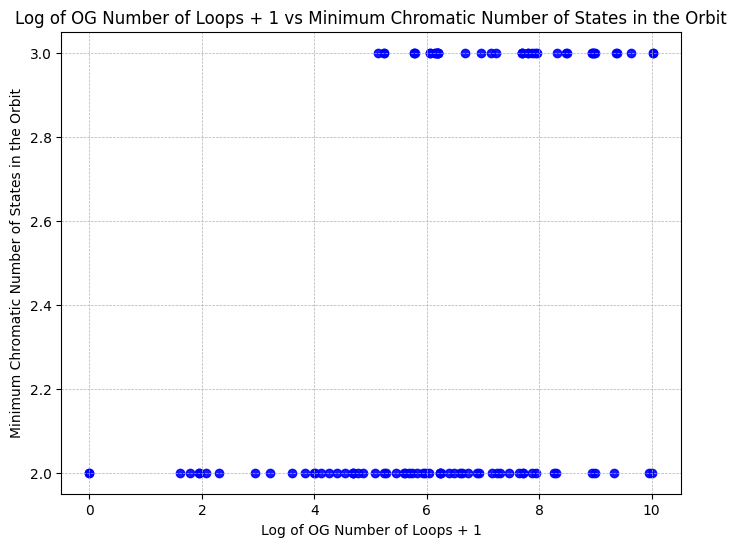

In [415]:
#6
#use offset for log(x)
x = np.log(data_og_number_of_loops+1)
x_label = "Log of OG Number of Loops + 1"

y = data_og_minimum_chromatic_number_in_OG
y_label = "Minimum Chromatic Number of States in the Orbit"

plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: 0.8590
P-value: 4.0069e-31


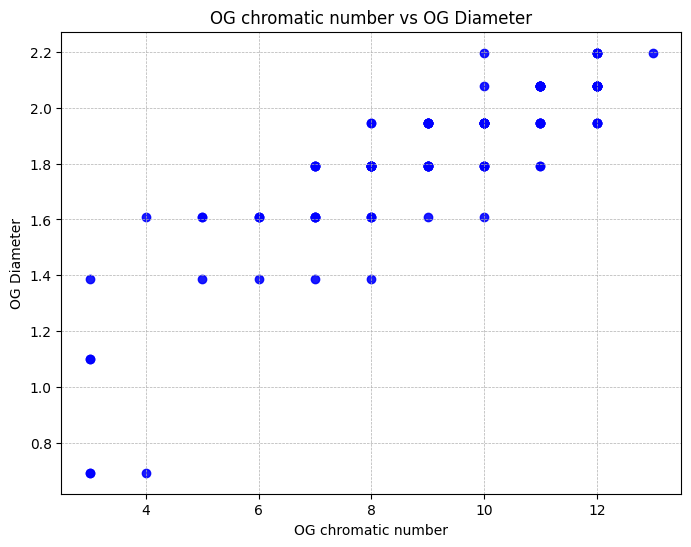

In [416]:
#5
x = data_og_chrom_number
x_label = "OG chromatic number"

y = np.log(data_og_diameter)
y_label = "OG Diameter"

plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: 0.8863
P-value: 1.5321e-35


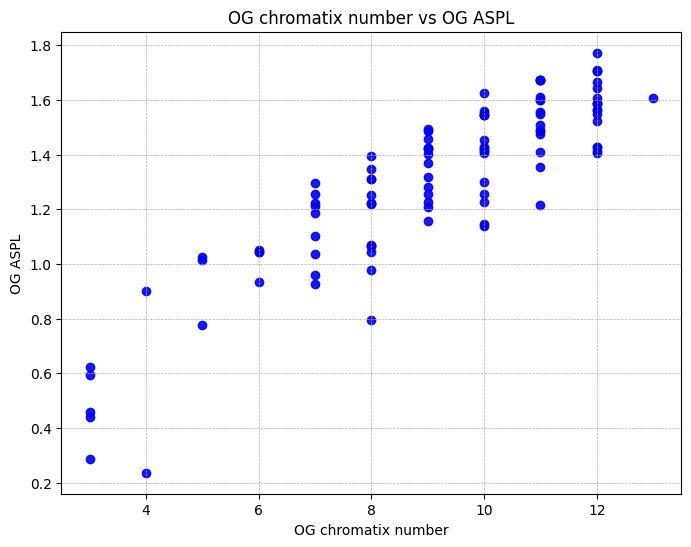

In [417]:
#4
x = data_og_chrom_number
x_label = "OG chromatix number"

y = np.log(data_og_aspl)
y_label = "OG ASPL"

plot_coef_and_find_pearson(x,y,x_label,y_label)


Pearson correlation coefficient: -0.9194
P-value: 9.9100e-43


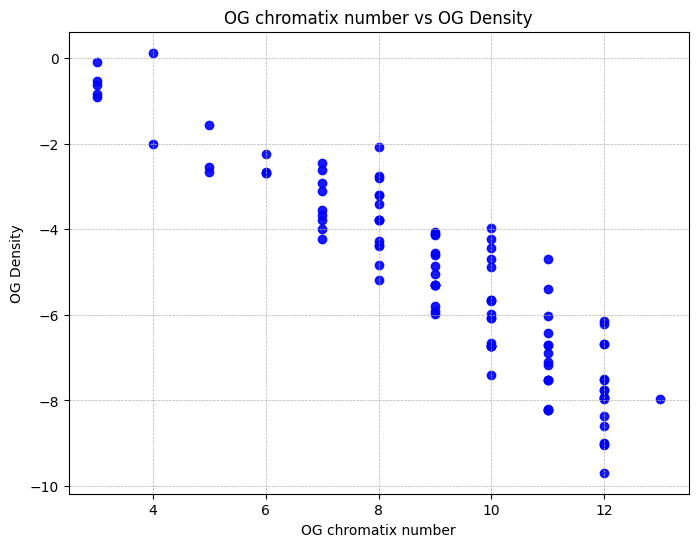

In [418]:
#3
x = data_og_chrom_number
x_label = "OG chromatix number"

y = np.log(data_og_density)
y_label = "OG Density"

plot_coef_and_find_pearson(x,y,x_label,y_label)


Pearson correlation coefficient: 0.5943
P-value: 3.6452e-11


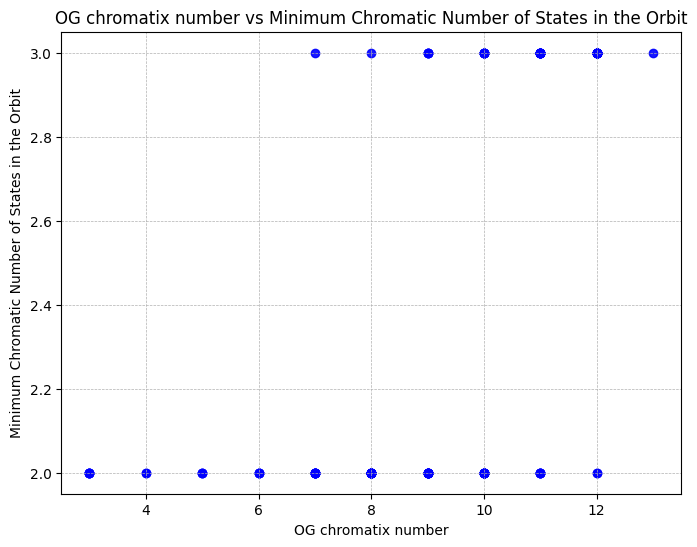

In [419]:
#2
x = data_og_chrom_number
x_label = "OG chromatix number"

y = data_og_minimum_chromatic_number_in_OG
y_label = "Minimum Chromatic Number of States in the Orbit"

plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.6175
P-value: 3.7235e-12


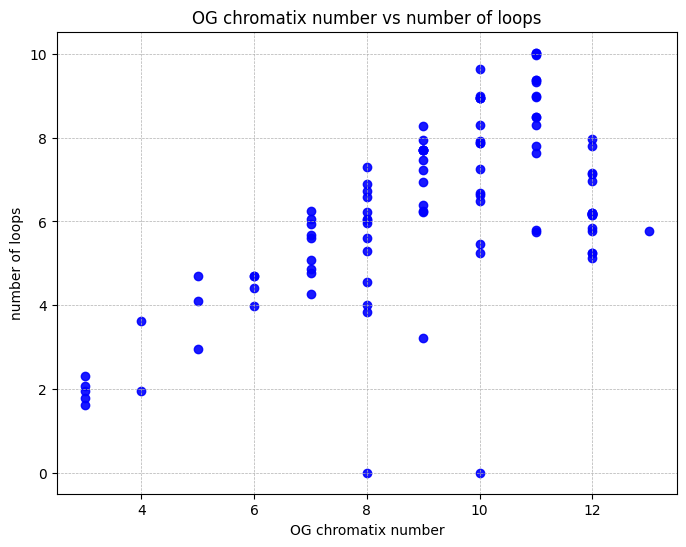

In [420]:
#1
x = data_og_chrom_number
x_label = "OG chromatix number"

# Offset needed to avoid log(0)
y = np.log(data_og_number_of_loops + 1)
y_label = "number of loops"

plot_coef_and_find_pearson(x,y,x_label,y_label)


In [421]:
len(help_array)
help_array

['data_og_chrom_number',
 'data_og_number_of_loops',
 'data_og_minimum_chromatic_number_in_OG',
 'data_og_density',
 'data_og_aspl',
 'data_og_diameter']

In [422]:
len(pearson_dictionary)

15

In [423]:
pearson_dictionary

{'ASPL OG vs Diameter of OG': {'coef': 0.9391325848263337,
  'pvalue': 1.150878190103296e-48},
 'Log Density OG vs Diameter of OG': {'coef': -0.9369185262055827,
  'pvalue': 6.615816175158404e-48},
 'Density OG vs ASPL of OG': {'coef': -0.9877149967260536,
  'pvalue': 3.050011820889902e-83},
 'Minimum Chromatic in OG vs Diameter of OG': {'coef': 0.5544945399147949,
  'pvalue': 1.2249097202894971e-09},
 'Minimum Chromatic in OG vs ASPL of OG': {'coef': 0.6027083517979684,
  'pvalue': 1.6280587228008866e-11},
 'Minimum Chromatic in OG vs Density of OG': {'coef': -0.6376619692289492,
  'pvalue': 4.382670530367771e-13},
 'Log of OG Number of Loops + 1 vs Diameter of OG': {'coef': 0.6265609506917398,
  'pvalue': 1.4510742111426209e-12},
 'Log of OG Number of Loops + 1 vs ASPL of OG': {'coef': 0.7528265926203498,
  'pvalue': 4.7233258362602236e-20},
 'Log of OG Number of Loops + 1 vs Density of OG': {'coef': -0.6914277404919515,
  'pvalue': 6.219989017159473e-16},
 'Log of OG Number of Loops

In [425]:
pearson_dictionary["ASPL OG vs Diameter of OG"]

{'coef': 0.9391325848263337, 'pvalue': 1.150878190103296e-48}